**Industrial ML for Smart Building Operations & Energy Optimization**

**Project Objective:**

The objective of this project is to design an industrial-grade anomaly detection system for smart building operations using the **Building Data Genome Project 2 (BDGP2)** dataset. The system aims to detect **operational and behavioral anomalies** in building energy usage that may indicate inefficiencies, abnormal scheduling, or potential faults in building operations.

This project explicitly avoids detecting sensor faults or data quality issues and instead focuses on anomalies that are meaningful for **energy optimization and operational decision-making**.

**Dataset Description:**

The BDGP2 dataset consists of time-series energy meter readings collected from multiple buildings across different sites. The dataset includes **eight energy types**:

* Electricity
* Water
* Gas
* Steam
* Hot Water
* Chilled Water
* Irrigation
* Solar

For each energy type, both raw and cleaned datasets are available. In addition, the dataset provides:

* **Weather data** at the site level
* **Building metadata** describing building characteristics

**Data Selection Rationale:**

This project uses **only the cleaned versions** of the energy datasets. The cleaned data removes:

* Sensor faults
* Extreme outliers
* Long continuous zero-value periods

This ensures that the anomaly detection system focuses on **operational deviations** rather than data quality issues. Raw data is intentionally excluded to avoid detecting anomalies that are already known to be sensor-related.

**Definition of Anomaly:**

In this project, an anomaly is defined as:

> **A deviation in a building’s energy usage pattern that is inconsistent with its own historical behavior and may indicate inefficiency, abnormal operation, or unexpected system behavior.**

Anomalies are detected **relative to each building’s baseline**, not by comparison across buildings.

**Building-Centric Modeling Strategy:**

Anomaly detection is performed **one building at a time**. Each building has unique operational characteristics, schedules, and energy baselines. Mixing data from multiple buildings would obscure what constitutes “normal” behavior.

The building identifier is used only to **select the relevant time series before modeling** and is **not used as a model input**.


**Energy-Wise Independent Detection:**

Even within a single building, each energy type represents a distinct physical and operational process. Therefore, anomalies are detected **independently for each energy type**, even if a building uses multiple energy meters.

This approach preserves interpretability and prevents interference between unrelated energy behaviors.

**Iterative & Scalable Pipeline Design:**

The notebook implements a **reusable and iterative pipeline**:

* A building ID is provided as input
* The system automatically identifies which energy types are available for that building
* The same anomaly detection logic is applied iteratively to each energy stream

This design mirrors real-world industrial systems and can be scaled to additional buildings by simply changing the building ID.

**Anomaly Detection Approach:**
An ensemble of **unsupervised machine learning models** is used to improve robustness:

* Isolation Forest
* Local Outlier Factor (LOF)
* Robust Covariance (Elliptic Envelope)

Final anomaly labels are determined using **majority voting** across models.

**Weather-Aware Interpretation (Level 1)**

Weather data is incorporated **after anomaly detection** for interpretation and contextual analysis. Weather variables are **not used as model inputs**, ensuring that anomalies are not masked or suppressed due to external conditions.

This Level 1 integration allows anomalies to be explained without altering detection logic.

**Metadata-Based Contextualization:**

Building metadata such as primary use, size, and site information is used to **contextualize and prioritize anomalies**. Metadata enhances interpretability but is intentionally excluded from model inputs to preserve building-specific anomaly definitions.

**Business Impact Analysis:**

Detected anomalies are translated into **estimated energy and cost impacts** using assumed unit energy costs. This step bridges the gap between technical anomaly detection and actionable business insights, supporting energy optimization decisions.

**Expected Outputs:**

The final system produces:

* Anomaly timestamps per energy type
* Visualizations highlighting anomalous behavior
* Weather and metadata context for interpretation
* Estimated financial impact of detected anomalies

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("claytonmiller/buildingdatagenomeproject2")

print("Path to dataset files:", path)

100%|██████████| 263M/263M [00:13<00:00, 20.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/claytonmiller/buildingdatagenomeproject2/versions/3


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
# BUILDING & ENERGY DISCOVERY
BUILDING_ID = "Panther_lodging_Cora"
DATASET_PATH = path
print(f"Selected Building: {BUILDING_ID}")

CLEANED_ENERGY_FILES = {
    "electricity": "electricity_cleaned.csv",
    "water": "water_cleaned.csv",
    "gas": "gas_cleaned.csv",
    "steam": "steam_cleaned.csv",
    "hotwater": "hotwater_cleaned.csv",
    "chilledwater": "chilledwater_cleaned.csv",
    "irrigation": "irrigation_cleaned.csv",
    "solar": "solar_cleaned.csv"
}

available_energies = []

for energy, filename in CLEANED_ENERGY_FILES.items():
    file_path = os.path.join(DATASET_PATH, filename)
    df_header = pd.read_csv(file_path, nrows=1)
    if BUILDING_ID in df_header.columns:
      available_energies.append(energy)

if len(available_energies) == 0:
    print(f"No cleaned energy data found for building: {BUILDING_ID}")
print("Energies available for analysis:")
for energy in available_energies:
    print(f"- {energy}")

Selected Building: Panther_lodging_Cora
Energies available for analysis:
- electricity
- water
- chilledwater
- irrigation


In [4]:
# METADATA CONTEXT
metadata_path = os.path.join(DATASET_PATH, "metadata.csv")
metadata_df = pd.read_csv(metadata_path)
if "building_id" in metadata_df.columns:
    building_meta = metadata_df[metadata_df["building_id"] == BUILDING_ID]
if building_meta.empty:
    print(f"No metadata found for building: {BUILDING_ID}")
    building_meta = None
else:
    print("Building metadata found.")
    display(building_meta)

Building metadata found.


,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
126,Panther_lodging_Cora,Panther,97.0,0.0,Lodging/residential,Residence Hall,17433.0,187647.0,28.517689,-81.379039,...,2007.0,NaN,NaN,NaN,NaN,151,NaN,NaN,NaN,NaN


In [5]:
# ENERGY-WISE DATA LOADING & TIME-SERIES PREPARATION
energy_timeseries = {}

for energy in available_energies:
    print(f"\nPreparing time series for energy: {energy}")
    file_name = f"{energy}_cleaned.csv"
    file_path = os.path.join(DATASET_PATH, file_name)
    df_energy = pd.read_csv(file_path)
    ts_df = df_energy[["timestamp", BUILDING_ID]].copy()
    ts_df.rename(columns={BUILDING_ID: "value"}, inplace=True)
    ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"])
    ts_df.sort_values("timestamp", inplace=True)
    ts_df.set_index("timestamp", inplace=True)
    ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
    ts_df["value"] = ts_df["value"].ffill().bfill()
    print(f"Time series prepared: {ts_df.shape[0]} rows")
    energy_timeseries[energy] = ts_df
    print(f"Saving file: {energy}_timeseries_{BUILDING_ID}.csv")
    ts_df.to_csv(f"{energy}_timeseries_{BUILDING_ID}.csv",index=True)


Preparing time series for energy: electricity
Time series prepared: 17544 rows
Saving file: electricity_timeseries_Panther_lodging_Cora.csv

Preparing time series for energy: water
Time series prepared: 17544 rows
Saving file: water_timeseries_Panther_lodging_Cora.csv

Preparing time series for energy: chilledwater
Time series prepared: 17544 rows
Saving file: chilledwater_timeseries_Panther_lodging_Cora.csv

Preparing time series for energy: irrigation
Time series prepared: 17544 rows
Saving file: irrigation_timeseries_Panther_lodging_Cora.csv


In [6]:
# FEATURE ENGINEERING
feature_data = {}
ROLLING_WINDOW = 24      # 24-hour context
LAG_FEATURES = [1, 24]   # previous hour, previous day
for energy, ts_df in energy_timeseries.items():
    print(f"\nFeature engineering for energy: {energy}")
    df = ts_df.copy()
    df["hour"] = df.index.hour
    df["day_of_week"] = df.index.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    df["rolling_mean"] = df["value"].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    df["rolling_std"] = df["value"].rolling(window=ROLLING_WINDOW, min_periods=1).std()
    df["deviation"] = df["value"] - df["rolling_mean"]
    for lag in LAG_FEATURES:
        df[f"lag_{lag}"] = df["value"].shift(lag)

    df_model = df.copy()
    df_model = df_model.ffill().bfill()
    feature_data[energy] = df_model
    print(f"Saving file: {energy}_features_{BUILDING_ID}.csv")
    df_model.to_csv(f"{energy}_features_{BUILDING_ID}.csv",index=True)
    print(f"Feature table shape: {df_model.shape}")
print("\nFeature engineering complete for all energies.")


Feature engineering for energy: electricity
Saving file: electricity_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering for energy: water
Saving file: water_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering for energy: chilledwater
Saving file: chilledwater_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering for energy: irrigation
Saving file: irrigation_features_Panther_lodging_Cora.csv
Feature table shape: (17544, 9)

Feature engineering complete for all energies.


In [7]:
# ENSEMBLE ANOMALY DETECTION
from sklearn.preprocessing import StandardScaler

anomaly_results = {}
CONTAMINATION_RATE = 0.03
for energy, df in feature_data.items():
    print(f"\nRunning anomaly detection for energy: {energy}")
    # Features for modeling
    features = ["value","rolling_mean","rolling_std","deviation","lag_1","lag_24","hour","day_of_week","is_weekend"]
    X = df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    iso = IsolationForest(
        contamination=CONTAMINATION_RATE,
        random_state=42,
        n_jobs=-1)
    iso_pred = iso.fit_predict(X_scaled)

    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=CONTAMINATION_RATE)
    lof_pred = lof.fit_predict(X_scaled)

    cov = EllipticEnvelope(
        contamination=CONTAMINATION_RATE,
        random_state=42
    )
    cov_pred = cov.fit_predict(X_scaled)

    iso_flag = (iso_pred == -1).astype(int)
    lof_flag = (lof_pred == -1).astype(int)
    cov_flag = (cov_pred == -1).astype(int)

    # Ensemble voting
    votes = iso_flag + lof_flag + cov_flag
    is_anomaly = (votes >= 2).astype(int)

    result_df = df.copy()
    result_df["iso_anomaly"] = iso_flag
    result_df["lof_anomaly"] = lof_flag
    result_df["cov_anomaly"] = cov_flag
    result_df["anomaly_votes"] = votes
    result_df["is_anomaly"] = is_anomaly

    anomaly_results[energy] = result_df
    print(f"Saving file: {energy}_anomaly_{BUILDING_ID}.csv")
    result_df.to_csv(f"anomaly_{energy}_{BUILDING_ID}.csv",index=True)

    # Summary
    total_anomalies = result_df["is_anomaly"].sum()
    print(f"Detected anomalies: {total_anomalies} / {len(result_df)}")

print("\nEnsemble anomaly detection complete for all energies.")


Running anomaly detection for energy: electricity


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Saving file: electricity_anomaly_Panther_lodging_Cora.csv
Detected anomalies: 376 / 17544

Running anomaly detection for energy: water


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Saving file: water_anomaly_Panther_lodging_Cora.csv
Detected anomalies: 451 / 17544

Running anomaly detection for energy: chilledwater


/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Saving file: chilledwater_anomaly_Panther_lodging_Cora.csv
Detected anomalies: 259 / 17544

Running anomaly detection for energy: irrigation


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/covariance/_robust_covariance.py:749: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


Saving file: irrigation_anomaly_Panther_lodging_Cora.csv
Detected anomalies: 202 / 17544

Ensemble anomaly detection complete for all energies.


In [8]:
# MODEL EVALUATION
evaluation_summary = []
for energy, result_df in anomaly_results.items():
    total_points = len(result_df)
    iso_anoms = result_df["iso_anomaly"].sum()
    lof_anoms = result_df["lof_anomaly"].sum()
    cov_anoms = result_df["cov_anomaly"].sum()
    ensemble_anoms = result_df["is_anomaly"].sum()
    evaluation_summary.append({
        "Energy Type": energy,
        "Total Data Points": total_points,
        "Isolation Forest Anomalies (%)": round(iso_anoms / total_points * 100, 2),
        "LOF Anomalies (%)": round(lof_anoms / total_points * 100, 2),
        "Robust Covariance Anomalies (%)": round(cov_anoms / total_points * 100, 2),
        "Ensemble Anomalies (%)": round(ensemble_anoms / total_points * 100, 2),})
evaluation_df = pd.DataFrame(evaluation_summary)
display(evaluation_df)

,Energy Type,Total Data Points,Isolation Forest Anomalies (%),LOF Anomalies (%),Robust Covariance Anomalies (%),Ensemble Anomalies (%)
0,electricity,17544,3.0,3.0,3.0,2.14
1,water,17544,3.0,3.0,3.0,2.57
2,chilledwater,17544,3.0,3.0,3.0,1.48
3,irrigation,17544,3.0,3.0,3.0,1.15


In [9]:
print("=" * 60)
print("VALUES TO HARDCODE INTO FASTAPI")
print("=" * 60)
print(f"CONTAMINATION_RATE = {CONTAMINATION_RATE}")
print(f"ROLLING_WINDOW = {ROLLING_WINDOW}")
print(f"MAJORITY_VOTE_THRESHOLD = 2")
print(f"FEATURES = ['value','rolling_mean','rolling_std','deviation','lag_1','lag_24','hour','day_of_week','is_weekend']")
print()
for _, row in evaluation_df.iterrows():
    print(f"{row['Energy Type']}:")
    print(f"  total_records  = {row['Total Data Points']}")
    print(f"  ensemble_anomalies = {round(row['Ensemble Anomalies (%)'] * row['Total Data Points'] / 100)}")
    print(f"  anomaly_rate   = {row['Ensemble Anomalies (%)']}%")

VALUES TO HARDCODE INTO FASTAPI
CONTAMINATION_RATE = 0.03
ROLLING_WINDOW = 24
MAJORITY_VOTE_THRESHOLD = 2
FEATURES = ['value','rolling_mean','rolling_std','deviation','lag_1','lag_24','hour','day_of_week','is_weekend']

electricity:
  total_records  = 17544
  ensemble_anomalies = 375
  anomaly_rate   = 2.14%
water:
  total_records  = 17544
  ensemble_anomalies = 451
  anomaly_rate   = 2.57%
chilledwater:
  total_records  = 17544
  ensemble_anomalies = 260
  anomaly_rate   = 1.48%
irrigation:
  total_records  = 17544
  ensemble_anomalies = 202
  anomaly_rate   = 1.15%


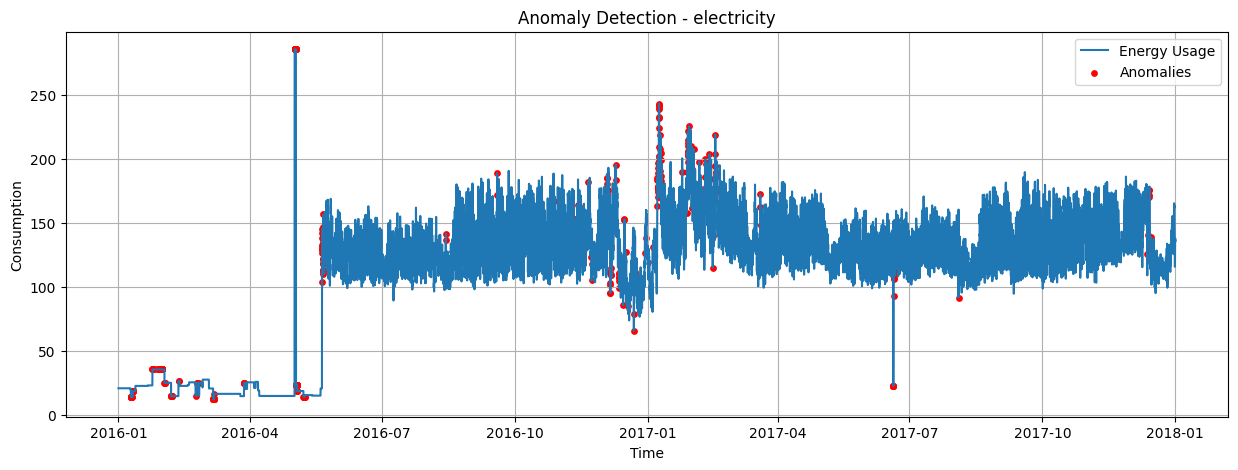

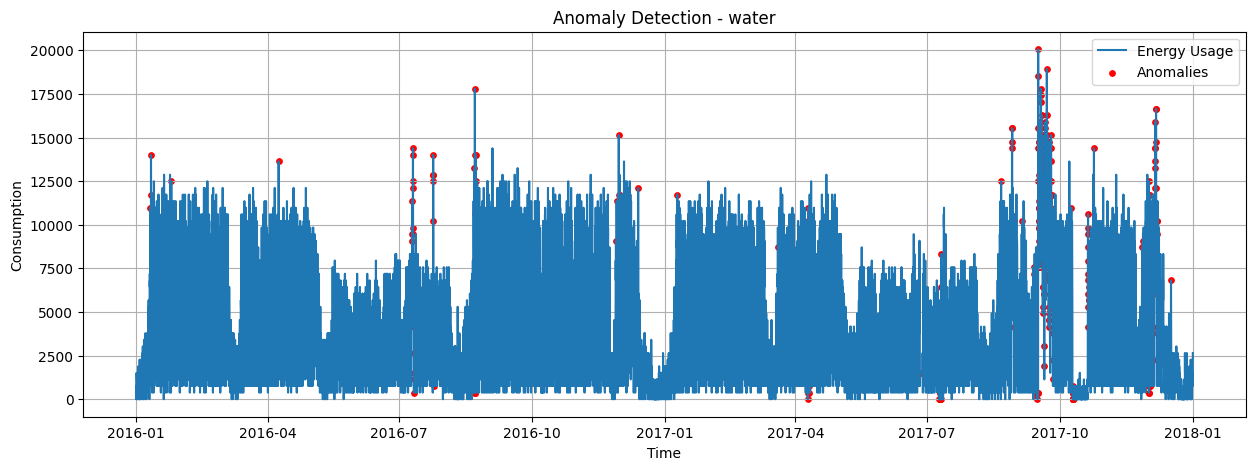

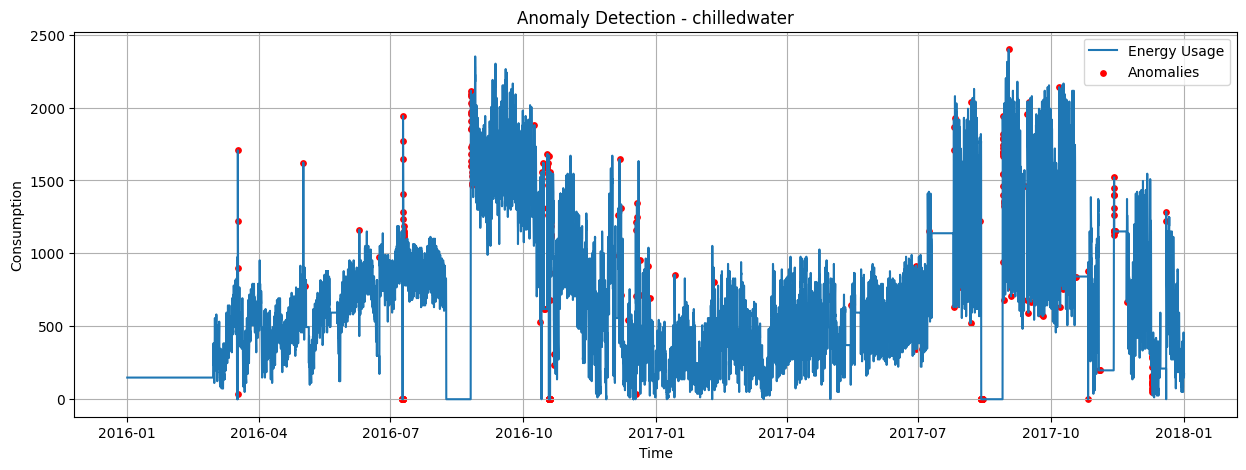

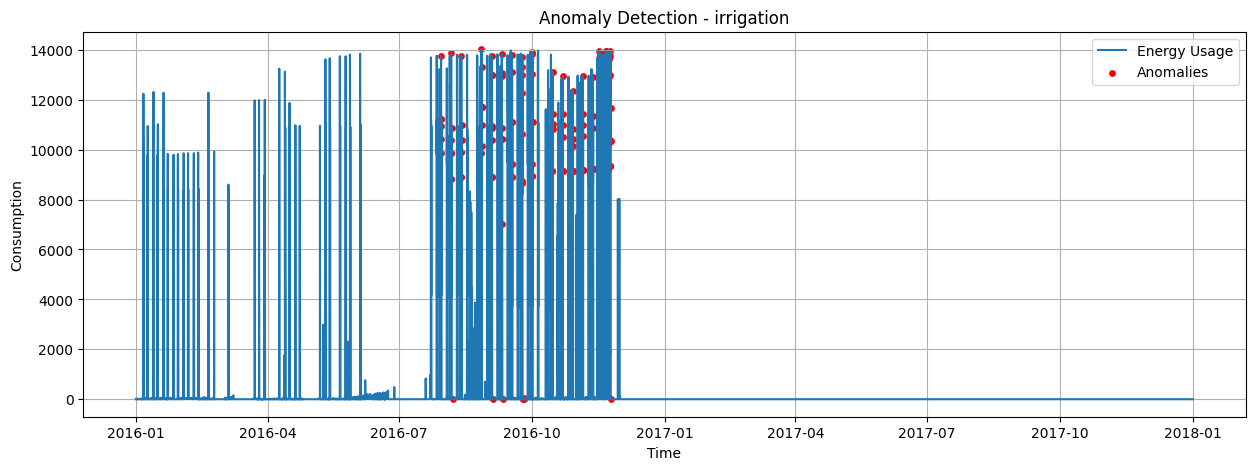

In [10]:
import matplotlib.pyplot as plt
for energy, df_plot in anomaly_results.items():
    if "value" not in df_plot.columns or "is_anomaly" not in df_plot.columns:
        print(f"Skipping {energy} (missing columns)")
        continue
    plt.figure(figsize=(15,5))
    # Plot normal usage
    plt.plot(df_plot.index, df_plot["value"], label="Energy Usage")
    # Plot anomalies
    anomalies = df_plot[df_plot["is_anomaly"] == 1]
    plt.scatter(anomalies.index, anomalies["value"], color='red', s=15, label="Anomalies")
    plt.title(f"Anomaly Detection - {energy}")
    plt.xlabel("Time")
    plt.ylabel("Consumption")
    plt.legend()
    plt.grid()
    plt.show()

In [11]:
COST_PER_UNIT = 0.08
cost_summary = []
for energy, df in anomaly_results.items():
    anomalies = df[df["is_anomaly"] == 1]
    if len(anomalies) == 0:
        continue
    normal_mean = df[df["is_anomaly"] == 0]["value"].mean()
    excess_energy = (anomalies["value"] - normal_mean).clip(lower=0)
    excess_cost = (excess_energy * COST_PER_UNIT).sum()
    cost_summary.append({
        "Energy Type": energy,
        "Num Anomalies": len(anomalies),
        "Excess Energy (above normal)": round(excess_energy.sum(), 2),
        "Excess Cost ($)": round(excess_cost, 2)})
cost_df = pd.DataFrame(cost_summary)
display(cost_df)

,Energy Type,Num Anomalies,Excess Energy (above normal),Excess Cost ($)
0,electricity,376,13307.39,1064.59
1,water,451,1818397.07,145471.77
2,chilledwater,259,111843.78,8947.50
3,irrigation,202,2048202.21,163856.18
